In [1]:
library(Seurat)
library(dplyr)
library(escape)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [2]:
so <- readRDS('vst2_clean.rds')

# Clustering

In [3]:
so <- NormalizeData(so) %>% FindVariableFeatures %>% ScaleData() %>% RunPCA() %>% RunUMAP(dims=1:30)

Normalizing layer: counts.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1

Normalizing layer: counts.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.2.1.1.1.1

Normalizing layer: counts.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1

Normalizing layer: counts.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.2.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.2.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



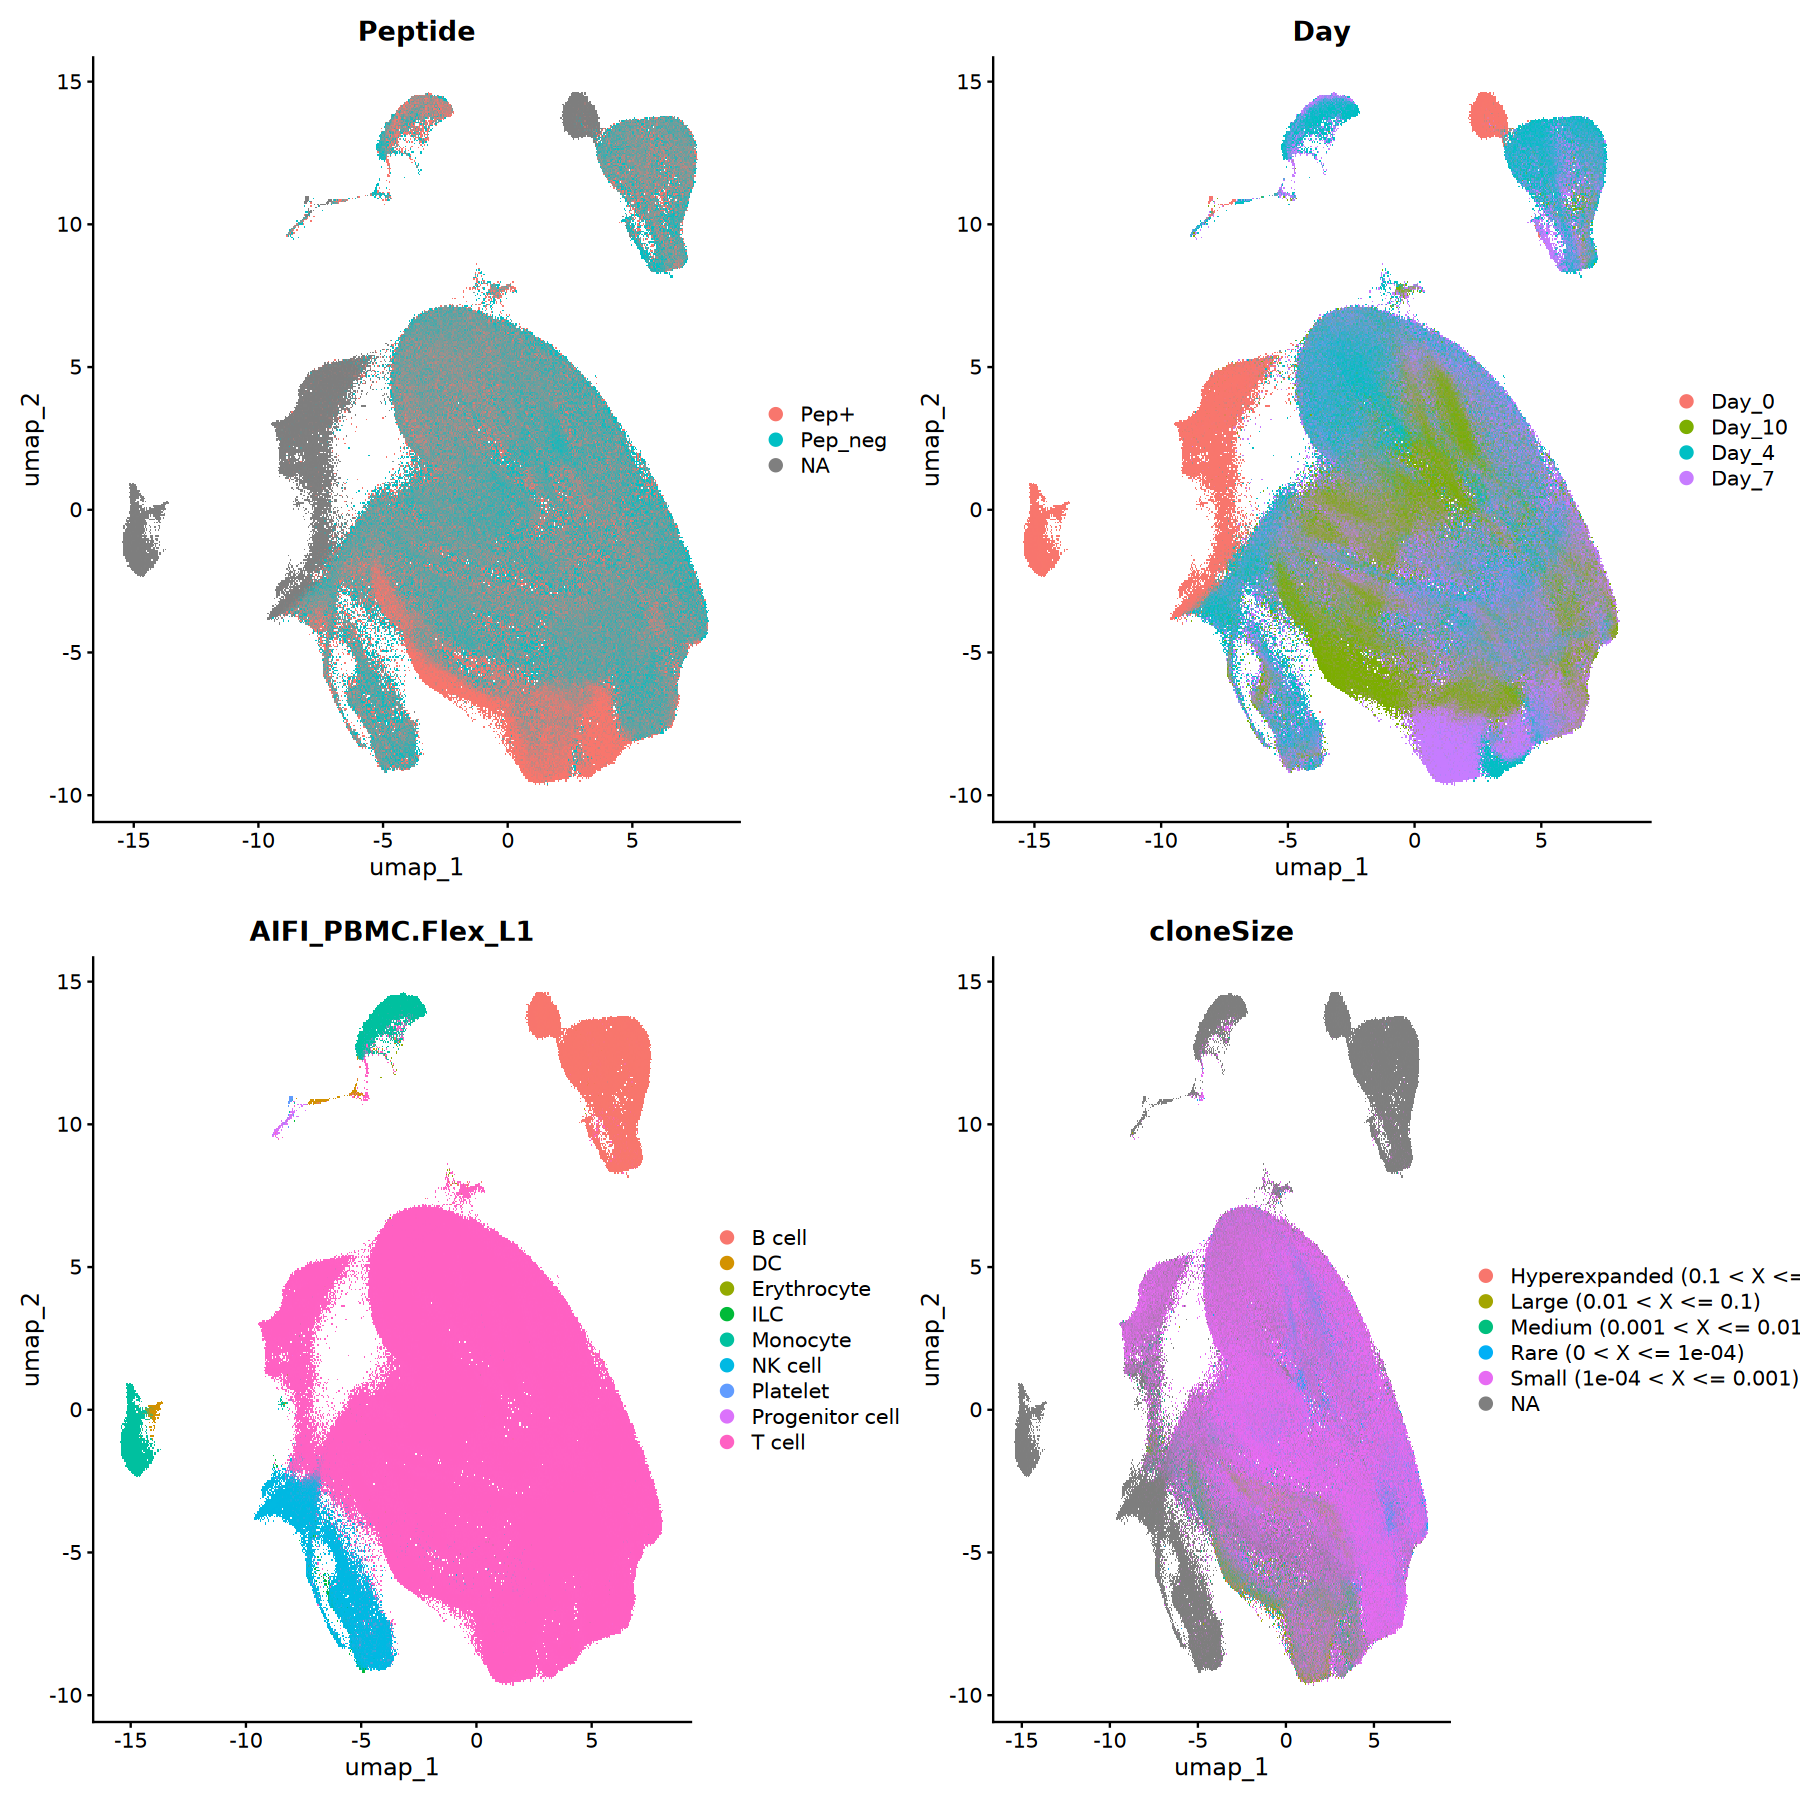

In [51]:
options(repr.plot.width = 15, repr.plot.height = 15)
p1 <- DimPlot(so, group.by = 'Peptide', shuffle = TRUE)
p2 <- DimPlot(so, group.by = 'Day', shuffle = TRUE)
p3 <- DimPlot(so, group.by = 'AIFI_PBMC.Flex_L1', shuffle = TRUE)
p4 <- DimPlot(so, group.by = 'cloneSize', shuffle = TRUE)
plot_grid(p1,p2,p3,p4, ncol=2)

In [5]:
saveRDS(so, 'temp_umap_vst2_full.rds')

In [2]:
so <- readRDS('temp_umap_vst2_full.rds')

In [ ]:
gs <- getGeneSets(species = "Homo sapiens",
                  library = "C2")

Loading required package: GSEABase

Warning message:
“package ‘GSEABase’ was built under R version 4.4.2”
Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.4.2”

Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, saveRDS, setdiff, table,
    tapply, union, unique, unsplit, which.max, which.min


Loading required package: Biobase

Warning message:
“package ‘Biobase’ was built under R version 4.4.2”
Welcome to Bioco

In [ ]:
cmv_sub <- gs[grepl(pattern = 'CMV', x = names(gs))]
length(cmv_sub)

[1] 39

In [ ]:
so <- JoinLayers(so)

In [ ]:
so

An object of class Seurat 
18129 features across 752834 samples within 1 assay 
Active assay: RNA (18129 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
saveRDS(so, 'temp_umap_vst2_full_joined.rds')

In [ ]:
so <- runEscape(so, 
               method = "ssGSEA",
               gene.sets = cmv_sub, 
               groups = 50000, 
               min.size = 3,
               new.assay.name = "escape.ssGSEA")

escape.matrix(): processing 16 chunk(s)...

! 1623 genes with constant values throughout the samples

! 2268 genes with constant non-zero values throughout the samples

! 1746 genes with constant values throughout the samples

! 2329 genes with constant non-zero values throughout the samples

! 1524 genes with constant values throughout the samples

! 2365 genes with constant non-zero values throughout the samples

! 1524 genes with constant values throughout the samples

! 2358 genes with constant non-zero values throughout the samples

! 1284 genes with constant values throughout the samples

! 2600 genes with constant non-zero values throughout the samples

! 1203 genes with constant values throughout the samples

! 2681 genes with constant non-zero values throughout the samples

! 1244 genes with constant values throughout the samples

! 2722 genes with constant non-zero values throughout the samples

! 1403 genes with constant values throughout the samples

! 2449 genes with const

In [ ]:
so

An object of class Seurat 
18168 features across 752834 samples within 2 assays 
Active assay: RNA (18129 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 1 other assay present: escape.ssGSEA
 2 dimensional reductions calculated: pca, umap

In [10]:
so$Peptide_Culture <- paste(so$Peptide, so$Culture, sep = '_')

In [16]:
so$Peptide_Culture_Day <- paste(so$Peptide, so$Culture, so$Day, sep = '_')

In [ ]:
saveRDS(so, 'temp_umap_vst2_full_ssgsea_cmv.rds')

In [2]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/minimal/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] escape_2.5.5       Seurat_5.3.0       SeuratObject_5.1.0 sp_2.2-0          

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3          jsonlite_2.0.0             
  [3] magrittr_2.0.3              spatstat.utils_3.1-5       
  [5] farver_2.1.2                zlibbioc_1.52.0            
  [7] ragg_